# 01 · Data Acquisition & Initial Profiling
### Credit Risk Prediction — Predicting Loan Default Risk

**Notebook 1 of a multi-part project.** Goal of this notebook: *acquire* the raw
data, understand its shape and quality, and identify what we are trying to
predict — before we touch any modeling. Everything here is exploratory and
read-only; we do not modify the source files.

## Why does predicting loan defaults matter?

Credit-card lending is, at its core, a **risk-management business**. When a bank
issues a card it is making an unsecured loan and betting the customer will pay it
back. Every such decision has two ways to be wrong:

- **Approve a bad applicant** → the customer falls delinquent, the bank writes
  off the balance and absorbs a direct financial loss.
- **Reject a good applicant** → the bank forgoes a profitable, creditworthy
  customer and the interest revenue they would have generated.

A credit-risk model lets a lender estimate an applicant's **probability of
default *before* extending credit**, so that approvals, credit limits and pricing
are set deliberately rather than by intuition. This is the quantitative engine
behind a **credit scorecard** — the objective, data-driven tool regulators and
risk teams rely on to make consistent, defensible lending decisions.

**The question this project answers:** *Given the information an applicant
provides at application time, how likely are they to become a seriously
delinquent ("bad") borrower?*

**A realistic twist — the label is not given.** Production credit data rarely
arrives with a clean `defaulted: yes/no` column. Instead we receive each
client's **monthly repayment history** and must *engineer* the target ourselves —
deciding what counts as "bad" and over what window. That label-construction step
is itself part of the analysis, and we take the first step toward it in this
notebook.

## 1. Setup — import libraries and configure the environment

**What:** Import the core data-handling and visualization libraries and set a
few display options so that wide tables and large numbers render readably.

**Why:** Pinning sensible defaults up front (showing all columns, suppressing
scientific notation for currency-sized numbers, a consistent plot style) keeps
every later cell legible and avoids repeating boilerplate. We only need `pandas`,
`numpy`, `matplotlib` and `seaborn` for data acquisition — the heavier modeling
libraries come into play in later notebooks.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Display options: see every column, and show full numbers (not 4.27e+05)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# Consistent, clean plot styling
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 13

print("Libraries imported. pandas", pd.__version__, "| numpy", np.__version__)

Libraries imported. pandas 2.3.3 | numpy 2.2.6


## 2. Load the raw data

**What:** Read the two source tables from `data/raw/` into pandas DataFrames.
`application_record.csv` holds one row per applicant (who they are at application
time); `credit_record.csv` holds the monthly repayment history (one row per
client per month) that we will later turn into the prediction target. The two
tables share a common client `ID`.

**Why:** Keeping the raw files untouched in `data/raw/` and loading copies into
memory follows the standard "raw data is immutable" practice — every
transformation happens in code and is reproducible, and we can always trace a
result back to the original source.

In [2]:
RAW_DIR = "../data/raw"

application = pd.read_csv(f"{RAW_DIR}/application_record.csv")
credit = pd.read_csv(f"{RAW_DIR}/credit_record.csv")

print(f"application_record loaded: {application.shape[0]:,} rows x {application.shape[1]} columns")
print(f"credit_record loaded:      {credit.shape[0]:,} rows x {credit.shape[1]} columns")

application_record loaded: 438,557 rows x 18 columns
credit_record loaded:      1,048,575 rows x 3 columns


## 3. Profile `application_record` — shape, dtypes, and memory

**What:** Report the dimensions of the applications table, the data type of each
column, and how much memory it occupies.

**Why:** This is the first thing to check on any new dataset. The **shape** tells
us how many applicants and features we have; the **dtypes** reveal which columns
pandas read as numeric vs. text (and flag anything that was parsed
unexpectedly); and **memory usage** matters because ~440K rows is large enough
that careless type choices can slow everything down. Knowing this now informs
how we handle the data later.

In [3]:
print("Shape (rows, columns):", application.shape)
print(f"Memory footprint: {application.memory_usage(deep=True).sum() / 1024**2:,.1f} MB\n")
print("Data type of each column:")
print(application.dtypes)

Shape (rows, columns): (438557, 18)


Memory footprint: 251.2 MB

Data type of each column:
ID                       int64
CODE_GENDER             object
FLAG_OWN_CAR            object
FLAG_OWN_REALTY         object
CNT_CHILDREN             int64
AMT_INCOME_TOTAL       float64
NAME_INCOME_TYPE        object
NAME_EDUCATION_TYPE     object
NAME_FAMILY_STATUS      object
NAME_HOUSING_TYPE       object
DAYS_BIRTH               int64
DAYS_EMPLOYED            int64
FLAG_MOBIL               int64
FLAG_WORK_PHONE          int64
FLAG_PHONE               int64
FLAG_EMAIL               int64
OCCUPATION_TYPE         object
CNT_FAM_MEMBERS        float64
dtype: object


## 4. Eyeball the data — first and last rows

**What:** Display the first five and last five rows of the applications table.

**Why:** Summary statistics can hide problems that are obvious the moment you
look at actual records. Viewing the head **and** the tail (rather than just the
head) is a deliberate habit — it catches issues like the file being sorted,
trailing summary rows, or values that change character partway through. Note in
particular `DAYS_BIRTH` and `DAYS_EMPLOYED`, which are stored as **negative
counts of days back from the application date** — a quirk we will need to decode
later.

In [4]:
print("First 5 rows:")
display(application.head())

First 5 rows:


,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,"427,500.00",Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.00
1,5008805,M,Y,Y,0,"427,500.00",Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.00
2,5008806,M,Y,Y,0,"112,500.00",Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.00
3,5008808,F,N,Y,0,"270,000.00",Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.00
4,5008809,F,N,Y,0,"270,000.00",Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.00


In [5]:
print("Last 5 rows:")
display(application.tail())

Last 5 rows:


,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
438552,6840104,M,N,Y,0,"135,000.00",Pensioner,Secondary / secondary special,Separated,House / apartment,-22717,365243,1,0,0,0,NaN,1.00
438553,6840222,F,N,N,0,"103,500.00",Working,Secondary / secondary special,Single / not married,House / apartment,-15939,-3007,1,0,0,0,Laborers,1.00
438554,6841878,F,N,N,0,"54,000.00",Commercial associate,Higher education,Single / not married,With parents,-8169,-372,1,1,0,0,Sales staff,1.00
438555,6842765,F,N,Y,0,"72,000.00",Pensioner,Secondary / secondary special,Married,House / apartment,-21673,365243,1,0,0,0,NaN,2.00
438556,6842885,F,N,Y,0,"121,500.00",Working,Secondary / secondary special,Married,House / apartment,-18858,-1201,1,0,1,0,Sales staff,2.00


## 5. Structural summary — `.info()`

**What:** Print a compact technical summary: column names, non-null counts, and
dtypes in one view.

**Why:** `.info()` is the fastest way to spot **missing data** (any column whose
non-null count is below the total row count has gaps) and to confirm dtypes at a
glance. We will quantify the nulls precisely in the next section, but `.info()`
gives the first signal of where they live.

In [6]:
application.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 438557 entries, 0 to 438556
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ID                   438557 non-null  int64  
 1   CODE_GENDER          438557 non-null  object 
 2   FLAG_OWN_CAR         438557 non-null  object 
 3   FLAG_OWN_REALTY      438557 non-null  object 
 4   CNT_CHILDREN         438557 non-null  int64  
 5   AMT_INCOME_TOTAL     438557 non-null  float64
 6   NAME_INCOME_TYPE     438557 non-null  object 
 7   NAME_EDUCATION_TYPE  438557 non-null  object 
 8   NAME_FAMILY_STATUS   438557 non-null  object 
 9   NAME_HOUSING_TYPE    438557 non-null  object 
 10  DAYS_BIRTH           438557 non-null  int64  
 11  DAYS_EMPLOYED        438557 non-null  int64  
 12  FLAG_MOBIL           438557 non-null  int64  
 13  FLAG_WORK_PHONE      438557 non-null  int64  
 14  FLAG_PHONE           438557 non-null  int64  
 15  FLAG_EMAIL       

## 6. Statistical summary — `.describe()`

**What:** Generate descriptive statistics. We show numeric columns (count, mean,
std, min, quartiles, max) and, separately, categorical columns (unique values,
most frequent value and its count).

**Why:** This surfaces the **distribution and plausibility** of each field.
We are looking for red flags: implausible ranges, suspiciously large maxima
(e.g. income outliers), constant columns that carry no information, and the
positive `DAYS_EMPLOYED` values that the data dictionary tells us actually encode
*unemployed* applicants. Spotting these now shapes the cleaning plan later.

In [7]:
print("Numeric columns:")
display(application.describe().T)

Numeric columns:


,count,mean,std,min,25%,50%,75%,max
ID,"438,557.00","6,022,176.27","571,637.02","5,008,804.00","5,609,375.00","6,047,745.00","6,456,971.00","7,999,952.00"
CNT_CHILDREN,"438,557.00",0.43,0.72,0.00,0.00,0.00,1.00,19.00
AMT_INCOME_TOTAL,"438,557.00","187,524.29","110,086.85","26,100.00","121,500.00","160,780.50","225,000.00","6,750,000.00"
DAYS_BIRTH,"438,557.00","-15,997.90","4,185.03","-25,201.00","-19,483.00","-15,630.00","-12,514.00","-7,489.00"
DAYS_EMPLOYED,"438,557.00","60,563.68","138,767.80","-17,531.00","-3,103.00","-1,467.00",-371.00,"365,243.00"
FLAG_MOBIL,"438,557.00",1.00,0.00,1.00,1.00,1.00,1.00,1.00
FLAG_WORK_PHONE,"438,557.00",0.21,0.40,0.00,0.00,0.00,0.00,1.00
FLAG_PHONE,"438,557.00",0.29,0.45,0.00,0.00,0.00,1.00,1.00
FLAG_EMAIL,"438,557.00",0.11,0.31,0.00,0.00,0.00,0.00,1.00
CNT_FAM_MEMBERS,"438,557.00",2.19,0.90,1.00,2.00,2.00,3.00,20.00


In [8]:
print("Categorical (object) columns:")
display(application.describe(include="object").T)

Categorical (object) columns:


,count,unique,top,freq
CODE_GENDER,438557,2,F,294440
FLAG_OWN_CAR,438557,2,N,275459
FLAG_OWN_REALTY,438557,2,Y,304074
NAME_INCOME_TYPE,438557,5,Working,226104
NAME_EDUCATION_TYPE,438557,5,Secondary / secondary special,301821
NAME_FAMILY_STATUS,438557,5,Married,299828
NAME_HOUSING_TYPE,438557,6,House / apartment,393831
OCCUPATION_TYPE,304354,18,Laborers,78240


## 7. Missing-value analysis — counts and percentages

**What:** Compute, for every column, the number and the percentage of missing
(null) values, sorted from most-missing to least.

**Why:** Missing data drives concrete decisions — whether to drop a column,
impute it, or treat "missing" as its own category. Quantifying the gap **as a
percentage** (not just a raw count) is what makes columns comparable and tells us
how severe each gap is relative to the 440K-row total.

In [9]:
null_counts = application.isnull().sum()
null_pct = (null_counts / len(application) * 100)

null_summary = (
    pd.DataFrame({"missing_count": null_counts, "missing_pct": null_pct})
    .sort_values("missing_pct", ascending=False)
)
display(null_summary)

,missing_count,missing_pct
OCCUPATION_TYPE,134203,30.60
ID,0,0.00
CODE_GENDER,0,0.00
FLAG_OWN_CAR,0,0.00
CNT_CHILDREN,0,0.00
FLAG_OWN_REALTY,0,0.00
NAME_INCOME_TYPE,0,0.00
NAME_EDUCATION_TYPE,0,0.00
NAME_FAMILY_STATUS,0,0.00
AMT_INCOME_TOTAL,0,0.00


### Visualizing the missing values

**What:** Plot the missing-value percentage per column as a horizontal bar chart,
showing only the columns that actually have gaps.

**Why:** A chart communicates "where are the holes, and how big?" far faster than
a table of numbers — it is exactly the kind of figure a reviewer or stakeholder
can absorb in a second. Filtering to columns with `>0%` missing keeps the chart
focused on what matters.

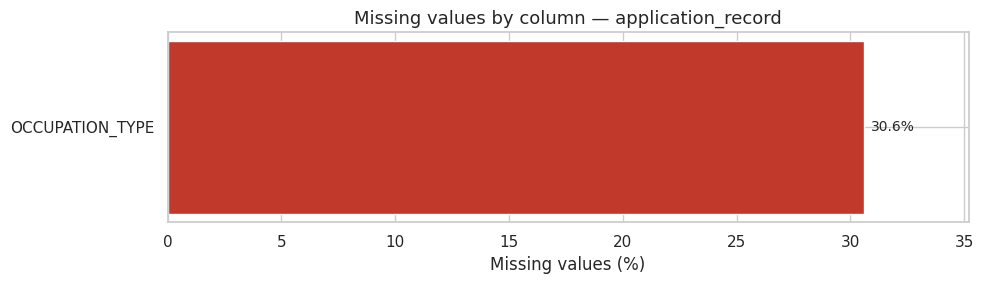

In [10]:
missing_only = null_summary[null_summary["missing_pct"] > 0].sort_values("missing_pct")

if missing_only.empty:
    print("No missing values in any column.")
else:
    fig, ax = plt.subplots(figsize=(10, max(3, 0.5 * len(missing_only))))
    bars = ax.barh(missing_only.index, missing_only["missing_pct"], color="#c0392b")
    ax.set_xlabel("Missing values (%)")
    ax.set_title("Missing values by column — application_record")
    for bar, pct in zip(bars, missing_only["missing_pct"]):
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
                f"{pct:.1f}%", va="center", fontsize=10)
    ax.set_xlim(0, missing_only["missing_pct"].max() * 1.15)
    plt.tight_layout()
    plt.savefig("../visualizations/01_missing_values.png", dpi=120, bbox_inches="tight")
    plt.show()

## 8. Profile `credit_record` — the repayment history

**What:** Apply the same first-look checks to the second table: shape, a preview
of the rows, dtypes, and a missing-value check.

**Why:** This table has a different grain — **one row per client per month**, not
one row per applicant. Understanding its structure is essential because it is the
raw material from which we will engineer the prediction target. The `STATUS`
column is the key field: it records how overdue each account was in a given
month.

In [11]:
print("Shape (rows, columns):", credit.shape)
print(f"Memory footprint: {credit.memory_usage(deep=True).sum() / 1024**2:,.1f} MB")
print(f"Unique clients in credit_record: {credit['ID'].nunique():,}\n")
print("Dtypes:")
print(credit.dtypes)
print("\nMissing values per column:")
print(credit.isnull().sum())

Shape (rows, columns): (1048575, 3)
Memory footprint: 74.0 MB
Unique clients in credit_record: 45,985

Dtypes:
ID                 int64
MONTHS_BALANCE     int64
STATUS            object
dtype: object

Missing values per column:
ID                0
MONTHS_BALANCE    0
STATUS            0
dtype: int64


In [12]:
print("First 8 rows (one client's monthly history):")
display(credit.head(8))

First 8 rows (one client's monthly history):


,ID,MONTHS_BALANCE,STATUS
0,5001711,0,X
1,5001711,-1,0
2,5001711,-2,0
3,5001711,-3,0
4,5001712,0,C
5,5001712,-1,C
6,5001712,-2,C
7,5001712,-3,C


### What do the `STATUS` codes mean?

Per the data dictionary, `STATUS` encodes the delinquency of an account in a
given month:

| Code | Meaning |
|------|---------|
| `0` | 1–29 days past due |
| `1` | 30–59 days past due |
| `2` | 60–89 days past due |
| `3` | 90–119 days past due |
| `4` | 120–149 days past due |
| `5` | 150+ days overdue / written off (bad debt) |
| `C` | Paid off that month |
| `X` | No loan for the month |

**What:** Tabulate how often each status code appears, as a count and a share of
all client-month records.

**Why:** This distribution tells us how common serious delinquency is in the raw
history, which directly informs how we define "bad" and previews the **class
imbalance** we will have to manage during modeling.

In [13]:
status_dist = (
    credit["STATUS"].value_counts(dropna=False)
    .rename_axis("STATUS")
    .to_frame("count")
)
status_dist["pct"] = status_dist["count"] / len(credit) * 100
display(status_dist)

,count,pct
STATUS,,
C,442031,42.16
0,383120,36.54
X,209230,19.95
1,11090,1.06
5,1693,0.16
2,868,0.08
3,320,0.03
4,223,0.02


## 9. Identifying the target variable

There is **no ready-made target column** — predicting credit risk first requires
us to *define* what we are predicting. We construct a binary label at the
**client** level from the monthly `STATUS` history.

**Definition used here:** a client is labelled **bad (`1`)** if *any* month in
their history shows **60+ days past due** — i.e. `STATUS` in `{2, 3, 4, 5}`.
Otherwise the client is **good (`0`)**.

**Why this threshold?** In credit-risk practice, being **60–90+ days past due**
("60+ DPD") is a widely used definition of a serious delinquency / default
event — it is severe enough to signal genuine credit risk, while not so rare
that almost no one qualifies. Codes `0` and `1` (under 60 days late) are treated
as good, since short, occasional lateness is common and not strongly predictive
of default on its own. Codes `C` (paid off) and `X` (no loan) are clearly
non-delinquent.

> **Note — this is a starting definition, not the final word.** A more rigorous
> approach is **vintage analysis**: track each cohort of accounts over a fixed
> performance window (e.g. "ever 60+ DPD within 18 months of opening") so that
> every client is judged over a comparable observation period. We flag that as
> future work; for this acquisition notebook the simple "ever 60+ DPD"
> definition is enough to identify the target and reveal the class balance.

**What:** Aggregate the monthly records to one row per client and derive the
binary label.

**Why:** The model predicts a single outcome per applicant, so the
client-by-month history must be collapsed to a single client-level target before
it can be joined to `application_record`.

In [14]:
# Codes that represent a serious delinquency (60+ days past due)
BAD_STATUSES = {"2", "3", "4", "5"}

# For each client, flag whether ANY month hit a "bad" status
credit["is_bad_month"] = credit["STATUS"].isin(BAD_STATUSES)
client_label = (
    credit.groupby("ID")["is_bad_month"].max()
    .astype(int)
    .rename("target")
    .reset_index()
)

print(f"Distinct clients labelled: {len(client_label):,}")
print("\nTarget value counts (0 = good, 1 = bad):")
print(client_label["target"].value_counts())
display(client_label.head())

Distinct clients labelled: 45,985

Target value counts (0 = good, 1 = bad):
target
0    45318
1      667
Name: count, dtype: int64


,ID,target
0,5001711,0
1,5001712,0
2,5001713,0
3,5001714,0
4,5001715,0


## 10. Class distribution — how (im)balanced is the target?

**What:** Show the share of good vs. bad clients, both as a table and as a bar
chart.

**Why:** The balance between classes is one of the single most important facts
about a classification problem. Credit default is a **rare event**, so we expect
a small minority of "bad" clients. A severe imbalance means that plain accuracy
is a misleading metric (a model that predicts "everyone is good" would score very
high while being useless), and it dictates that later notebooks use
imbalance-aware techniques (resampling, class weights) and metrics like
precision/recall, ROC-AUC and PR-AUC. Measuring it now sets that expectation.

In [15]:
class_counts = client_label["target"].value_counts().sort_index()
class_pct = client_label["target"].value_counts(normalize=True).sort_index() * 100

summary = pd.DataFrame({
    "class": ["Good (0)", "Bad (1)"],
    "count": class_counts.values,
    "pct": class_pct.values,
})
display(summary)

imbalance_ratio = class_counts[0] / class_counts[1]
print(f"Imbalance ratio (good : bad) = {imbalance_ratio:,.1f} : 1")
print(f"Bad clients make up {class_pct[1]:.1f}% of all labelled clients.")

,class,count,pct
0,Good (0),45318,98.55
1,Bad (1),667,1.45


Imbalance ratio (good : bad) = 67.9 : 1
Bad clients make up 1.5% of all labelled clients.


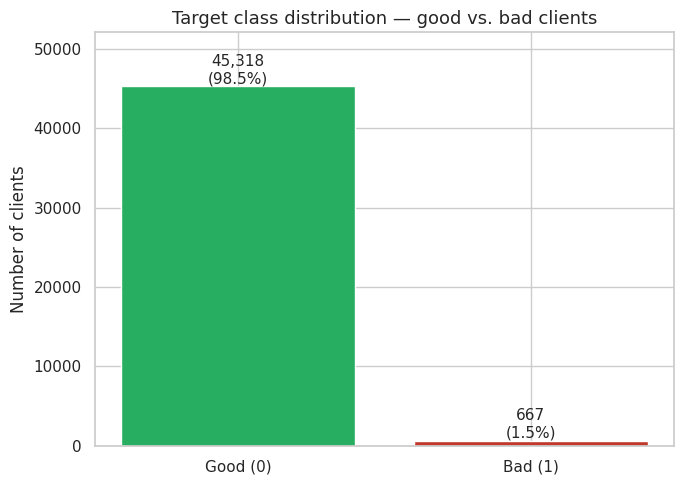

In [16]:
fig, ax = plt.subplots(figsize=(7, 5))
colors = ["#27ae60", "#c0392b"]
bars = ax.bar(["Good (0)", "Bad (1)"], class_counts.values, color=colors)
ax.set_ylabel("Number of clients")
ax.set_title("Target class distribution — good vs. bad clients")
for bar, cnt, pct in zip(bars, class_counts.values, class_pct.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f"{cnt:,}\n({pct:.1f}%)", ha="center", va="bottom", fontsize=11)
ax.set_ylim(0, class_counts.max() * 1.15)
plt.tight_layout()
plt.savefig("../visualizations/01_class_distribution.png", dpi=120, bbox_inches="tight")
plt.show()

## 11. How many applicants actually have a credit history?

**What:** Check the overlap between the two tables — how many applicants in
`application_record` have a matching label from `credit_record`.

**Why:** The model can only be trained on clients that appear in **both** tables
(we need features *and* a label). Knowing the size of that intersection now tells
us the true size of our modeling dataset and flags how many applications will be
unusable for supervised training because they have no repayment history.

In [17]:
app_ids = set(application["ID"])
credit_ids = set(client_label["ID"])
overlap = app_ids & credit_ids

print(f"Applicants in application_record: {len(app_ids):,}")
print(f"Clients with an engineered label: {len(credit_ids):,}")
print(f"Overlap (usable for modeling):    {len(overlap):,}")
print(f"Applicants with NO credit history: {len(app_ids - credit_ids):,}")
print(f"\n=> ~{len(overlap) / len(app_ids) * 100:.1f}% of applicants can be matched to a label.")

Applicants in application_record: 438,510
Clients with an engineered label: 45,985
Overlap (usable for modeling):    36,457
Applicants with NO credit history: 402,053

=> ~8.3% of applicants can be matched to a label.


## 12. Initial observations

A summary of what this first pass over the data revealed. These points become the
to-do list for the next notebooks (target engineering, cleaning, and EDA).

- **Two tables, joined by `ID`.** `application_record` (~438K applicants, 18
  features) describes who the applicant is; `credit_record` (~1M client-months)
  describes how they repaid. They must be joined on `ID` to build a supervised
  dataset.
- **The target had to be engineered.** No default flag is provided. We defined
  **bad = ever 60+ days past due** (`STATUS` ∈ {2,3,4,5}) at the client level;
  a more rigorous **vintage-analysis** window is noted as future work.
- **The classes are heavily imbalanced.** Bad clients are a small minority, so
  accuracy is the wrong headline metric and imbalance-aware methods will be
  needed downstream.
- **`OCCUPATION_TYPE` has substantial missing values** (~30%) — a cleaning /
  imputation decision is required; "missing" may itself be informative.
- **`DAYS_BIRTH` and `DAYS_EMPLOYED` are encoded as negative day-counts** from
  the application date and must be converted to interpretable ages / tenure.
  Positive `DAYS_EMPLOYED` values are a sentinel for **unemployed** applicants
  and need special handling.
- **`FLAG_MOBIL` looks constant** (almost everyone has a value of 1) — likely a
  zero-variance column that adds no predictive signal and can probably be
  dropped.
- **Only a subset of applicants have a credit history**, so the usable modeling
  set is the *intersection* of the two tables, not the full application file.
- **Potential duplicate / repeated applicants** are worth checking before
  modeling, since the same person could appear more than once.

➡️ **Next notebook (`02`):** formalize the target with vintage analysis, join the
tables, and carry out a full exploratory data analysis (EDA) of how each feature
relates to credit risk.